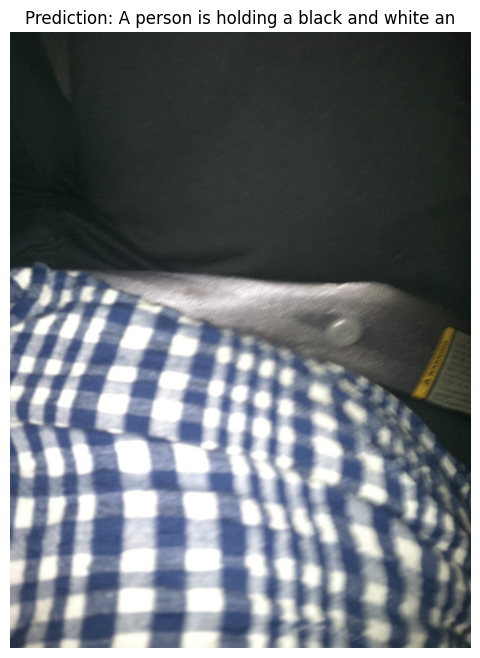

Max length: 40
File: VizWiz_train_00008123.jpg
Validation split settings: val_ratio=0.1, split_seed=42

Prediction:
A person is holding a black and white an

Ground-truth captions:
1. A person is sitting and wearing their seatbelt in a car.
2. a person's torso with a blue and white checked shirt a gray seat belt across their lap and dark pants
3. A piece of blue and white checkered fabric against a car's seat belt.
4. A gray seat belt lies across the lap of a person wearing a blue and white checkered shirt and black pants.
5. Quality issues are too severe to recognize visual content.


In [69]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

from captioning import load_checkpoint
from dataset import VizWizCaptionDataset, load_annotations, split_train_val

run_dir = Path("runs_pretrained/baseline_resnet18_gru_char")
data_dir = Path("data")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, tokenizer, config = load_checkpoint(run_dir / "best.pt", device=device)

# Fallback to the training defaults if the checkpoint config does not store them
val_ratio = config.get("val_ratio", 0.1)
split_seed = config.get("split_seed", 42)

all_samples = load_annotations(data_dir / "annotations" / "train.json")
_, val_samples = split_train_val(
    all_samples,
    val_ratio=val_ratio,
    seed=split_seed,
)

sample = random.choice(val_samples)

transform = VizWizCaptionDataset(
    data_dir=data_dir,
    samples=[],
    tokenizer=tokenizer,
    max_len=config["max_len"],
    training=False,
).transform

image_path = data_dir / "train" / sample.file_name
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    generated = model.generate(
        images=image_tensor,
        sos_id=tokenizer.sos_id,
        eos_id=tokenizer.eos_id,
        max_len= config["max_len"],
    )

# print("Generated token IDs:", generated[0].tolist())
pred_caption = tokenizer.decode(generated[0].tolist())

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {pred_caption}")
plt.show()

print(f"Max length: {config['max_len']}")
print("File:", sample.file_name)
print(f"Validation split settings: val_ratio={val_ratio}, split_seed={split_seed}")

print("\nPrediction:")
print(pred_caption)

print("\nGround-truth captions:")
for i, ref in enumerate(sample.captions, 1):
    print(f"{i}. {ref}")


In [70]:
from pathlib import Path
import json
import statistics

annotations_path = Path("data/annotations/train.json")

payload = json.loads(annotations_path.read_text())
annotations = payload.get("annotations", [])

captions = [
    ann.get("caption", "").strip()
    for ann in annotations
    if not ann.get("is_rejected", False) and ann.get("caption", "").strip()
]

lengths = [len(caption) for caption in captions]

max_caption = max(captions, key=len)
max_length_chars = len(max_caption)
mean_length_chars = statistics.mean(lengths)
median_length_chars = statistics.median(lengths)

print("Number of valid captions:", len(captions))
print("Mean caption length (characters):", round(mean_length_chars, 2))
print("Median caption length (characters):", median_length_chars)
print("Max caption length (characters):", max_length_chars)
print("\nLongest caption:")
print(max_caption)


Number of valid captions: 113987
Mean caption length (characters): 61.54
Median caption length (characters): 58
Max caption length (characters): 639

Longest caption:
a placard showing men climbing off of a boat text reads " to the lcpl during the 1930s Higgins tried to interest the u s navy in adapting his shallow-draft eureka for use as an amphibious landing craft the navy showed little interest but Higgins persisted after a long struggle he finally secured a government contract to build modified eurekas for military use the new boat was called the lcp landing craft personnel and later the lcpl landing craft personnel large in its most advanced form the lcpl measured 36 feet in length it could transport men from ships offshore directly onto a beach then retract itself turn and head back to sea


In [71]:
from pathlib import Path
import json
import statistics
import re

annotations_path = Path("data/annotations/train.json")

payload = json.loads(annotations_path.read_text())
annotations = payload.get("annotations", [])

captions = [
    ann.get("caption", "").strip()
    for ann in annotations
    if not ann.get("is_rejected", False) and ann.get("caption", "").strip()
]

word_re = re.compile(r"\w+|[^\w\s]")

tokenized_captions = [word_re.findall(caption.lower()) for caption in captions]
lengths = [len(tokens) for tokens in tokenized_captions]

max_idx = max(range(len(tokenized_captions)), key=lambda i: len(tokenized_captions[i]))
max_caption = captions[max_idx]
max_tokens = tokenized_captions[max_idx]

mean_length_words = statistics.mean(lengths)
median_length_words = statistics.median(lengths)
max_length_words = len(max_tokens)

print("Number of valid captions:", len(captions))
print("Mean caption length (word-level tokens):", round(mean_length_words, 2))
print("Median caption length (word-level tokens):", median_length_words)
print("Max caption length (word-level tokens):", max_length_words)
print("\nCaption with most word-level tokens:")
print(max_caption)
print("\nTokenized version:")
print(max_tokens)


Number of valid captions: 113987
Mean caption length (word-level tokens): 12.76
Median caption length (word-level tokens): 11
Max caption length (word-level tokens): 129

Caption with most word-level tokens:
Here is a metallic silver food bag sitting on a counter, the bag has a seal and yellow label that says Blueberry Nut 12 oz (340g), Nutrition Facts, serving size 1 oz (28g/about 1/4 cup), servings per container 12, ingredients: almonds, dried sweetened blueberries (cultivated blueberries, sugar, sunflower oil), walnuts pecans, contains along, walnut and pecan, may contain other tree buts, 100% satisfaction guaranteed, and they said you can't guarantee happiness, then it has the nutritional facts information so the total fat 12g, calories 150, cholesterol 0mg, sodium 0mg, total carbohydrate 10g and protein 4g.

Tokenized version:
['here', 'is', 'a', 'metallic', 'silver', 'food', 'bag', 'sitting', 'on', 'a', 'counter', ',', 'the', 'bag', 'has', 'a', 'seal', 'and', 'yellow', 'label', '